In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from prophet import Prophet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [22]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [23]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   flo

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [24]:
df.drop_duplicates(inplace=True)

df.dropna(inplace=True)

print("Missing Values")
print(df.isnull().sum())

print("\nFinal Shape")
print(df.shape)

Missing Values
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Final Shape
(9994, 21)


In [25]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter
df["Day"] = df["Order Date"].dt.day
df["Weekday"] = df["Order Date"].dt.day_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Day,Weekday
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4,8,Tuesday
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4,8,Tuesday
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2,12,Sunday
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4,11,Sunday
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4,11,Sunday


In [26]:
total_sales = df["Sales"].sum()

total_profit = df["Profit"].sum()

total_orders = df["Order ID"].nunique()

profit_margin = (total_profit / total_sales) * 100

print("Total Sales :", round(total_sales,2))
print("Total Profit :", round(total_profit,2))
print("Total Orders :", total_orders)
print("Profit Margin :", round(profit_margin,2),"%")

Total Sales : 2297200.86
Total Profit : 286397.02
Total Orders : 5009
Profit Margin : 12.47 %


In [28]:
monthly_sales = df.groupby(
    pd.Grouper(
        key="Order Date",
        freq="M"
    )
)["Sales"].sum().reset_index()

fig = px.line(
    monthly_sales,
    x="Order Date",
    y="Sales",
    title="Monthly Sales Trend"
)

fig.show()

In [29]:
category_sales = df.groupby(
    "Category"
)["Sales"].sum().reset_index()

fig = px.bar(
    category_sales,
    x="Category",
    y="Sales",
    title="Sales by Category"
)

fig.show()

In [30]:
region_sales = df.groupby(
    "Region"
)["Sales"].sum().reset_index()

fig = px.pie(
    region_sales,
    names="Region",
    values="Sales",
    title="Regional Sales Distribution"
)

fig.show()

In [31]:
top_products = df.groupby(
    "Product Name"
)["Sales"].sum().sort_values(
    ascending=False
).head(10)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [32]:
sales_data = df.groupby(
    "Order Date"
)["Sales"].sum().reset_index()

sales_data.columns = ["ds","y"]

sales_data.head()

,ds,y
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [33]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(sales_data)

In [34]:
future = model.make_future_dataframe(
    periods=90
)

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2014-01-03,1451.694034,-1339.018028,4153.653208,1451.694034,1451.694034,96.342359,96.342359,96.342359,419.731339,419.731339,419.731339,-323.388979,-323.388979,-323.388979,0.0,0.0,0.0,1548.036393
1,2014-01-04,1451.812178,-1717.664325,3727.813663,1451.812178,1451.812178,-399.119950,-399.119950,-399.119950,21.366500,21.366500,21.366500,-420.486450,-420.486450,-420.486450,0.0,0.0,0.0,1052.692228
2,2014-01-05,1451.930322,-1703.392118,3832.752958,1451.930322,1451.930322,-307.416317,-307.416317,-307.416317,203.612960,203.612960,203.612960,-511.029277,-511.029277,-511.029277,0.0,0.0,0.0,1144.514006
3,2014-01-06,1452.048467,-1321.111033,3982.604614,1452.048467,1452.048467,-182.199789,-182.199789,-182.199789,411.614941,411.614941,411.614941,-593.814730,-593.814730,-593.814730,0.0,0.0,0.0,1269.848678
4,2014-01-07,1452.166611,-2233.296179,3200.016016,1452.166611,1452.166611,-839.794939,-839.794939,-839.794939,-172.007872,-172.007872,-172.007872,-667.787067,-667.787067,-667.787067,0.0,0.0,0.0,612.371672


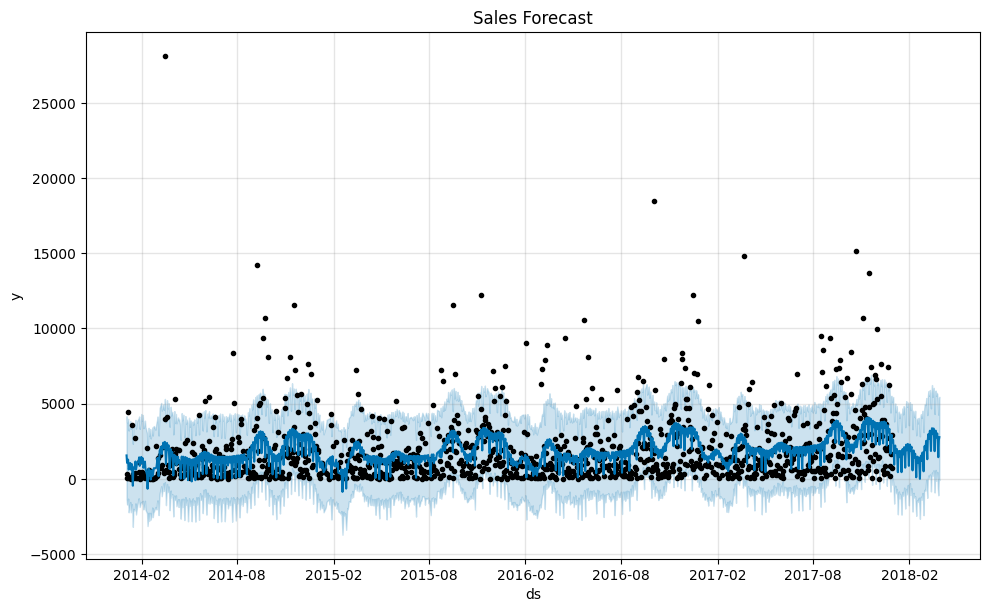

In [35]:
fig = model.plot(forecast)

plt.title("Sales Forecast")
plt.show()

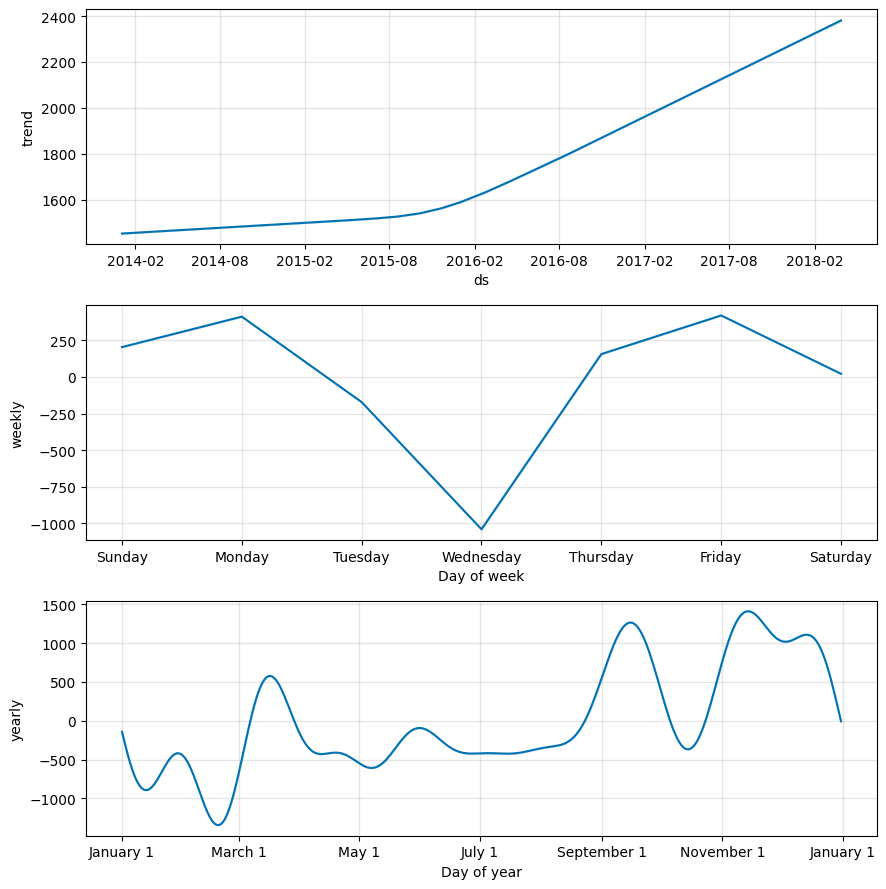

In [36]:
fig2 = model.plot_components(forecast)

plt.show()

In [37]:
forecast_plot = go.Figure()

forecast_plot.add_trace(
    go.Scatter(
        x=sales_data["ds"],
        y=sales_data["y"],
        mode="lines",
        name="Actual Sales"
    )
)

forecast_plot.add_trace(
    go.Scatter(
        x=forecast["ds"],
        y=forecast["yhat"],
        mode="lines",
        name="Forecast"
    )
)

forecast_plot.update_layout(
    title="Actual vs Forecast Sales",
    xaxis_title="Date",
    yaxis_title="Sales"
)

forecast_plot.show()

In [38]:
actual = sales_data["y"]

predicted = forecast["yhat"][:len(actual)]

mae = mean_absolute_error(
    actual,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))

MAE : 1402.97
RMSE : 2136.44


In [39]:
future_forecast = forecast[
    ["ds","yhat"]
].tail(90)

future_forecast.columns = [
    "Date",
    "Predicted Sales"
]

future_forecast.head(20)

,Date,Predicted Sales
1237,2017-12-31,2489.615921
1238,2018-01-01,2590.093354
1239,2018-01-02,1901.307789
1240,2018-01-03,931.585500
1241,2018-01-04,2031.948706
1242,2018-01-05,2206.055980
1243,2018-01-06,1725.899132
1244,2018-01-07,1835.166699
1245,2018-01-08,1979.886023
1246,2018-01-09,1343.365347


In [40]:
future_forecast.to_csv(
    "Sales_Forecast_90_Days.csv",
    index=False
)

print("Forecast File Saved")

Forecast File Saved


In [41]:
best_region = region_sales.loc[
    region_sales["Sales"].idxmax()
]

best_category = category_sales.loc[
    category_sales["Sales"].idxmax()
]

print("Best Region :", best_region["Region"])
print("Region Sales :", round(best_region["Sales"],2))

print()

print("Best Category :", best_category["Category"])
print("Category Sales :", round(best_category["Sales"],2))

Best Region : West
Region Sales : 725457.82

Best Category : Technology
Category Sales : 836154.03
